<a href="https://colab.research.google.com/github/AgrisData/ANOVA-AGRICOLA/blob/main/TP1/ANOVA_AGR%C3%8DCOLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANOVA & Kruska-Wallis**

In [2]:
#Librerías a utilizar
import scipy.stats as st
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

## **Rendimiento de maíz acorde a la densidad de siembra (Los Ríos) 🌽**


Evaluaremos 3 densidades de siembra en Los Rios y responderemos a la pregunta 👉 ¿Sembrar más tupido da más plata?
T1: 50k plantas/ha
T2: 60k plantas/ha
T3: 80k plantas/ha (Alta densidad)

In [3]:
data_maiz = {
    'Densidad': (['50k_Plantas']*25 + ['60k_Plantas']*25 + ['80k_Plantas']*25),
    'Rendimiento': np.concatenate([
        np.random.normal(110, 10, 25), # 50k
        np.random.normal(145, 12, 25), # 60k (¿El punto óptimo?)
        np.random.normal(130, 15, 25)  # 80k (Competencia por luz bajó el rinde)
    ])
}
df_maiz = pd.DataFrame(data_maiz)

In [4]:
grupo_maiz = [g for n,g in df_maiz.groupby('Densidad')['Rendimiento']] #Creamos el grupo

In [5]:
print(f"{'*'*20} RESUMEN ESTADÍSTICO {'*'*20} \n {df_maiz.groupby('Densidad')['Rendimiento'].agg(['count','mean','std']).round(3)\
                                                  .rename(columns={'count':'Cantidad','mean':'Media','std':'Desviación'})}")
print(f"{'*'*20} VERIFICACIÓN DE DATOS {'*'*20}")
_,p_shap = st.shapiro(df_maiz['Rendimiento'])
_,p_lev = st.levene(*grupo_maiz)
print(f"\nNormalidad (Shapiro): {p_shap:.4f} -> {'Ok' if p_shap>0.05 else 'Alerta'}")
print(f"Homocedasticidad (Levene): {p_lev:.4f} -> {'Ok' if p_lev>0.05 else 'Alerta'}")
print(f"\n{'*'*20} ANÁLISIS DE VARIANZA {'*'*20}")
test_func,test_name = (st.f_oneway,'ANOVA') if p_lev>0.05 else (st.kruskal, 'Kruskal-Wallis')
f_stat,p_val = test_func(*grupo_maiz)
print(f"---{test_name}--- \n F: {f_stat:.4f} | P_value: {p_val:.4f} -> {'Significativo' if p_val<0.05 else 'No Significativo'}")
print(f"\n{'*'*20} PRUEBA POST HOC {'*'*20}")
if p_val<0.05:
  print('\n',pairwise_tukeyhsd(endog=df_maiz['Rendimiento'], groups=df_maiz['Densidad'], alpha=0.05))
else:
  print("No requiere prueba Post Hoc")

******************** RESUMEN ESTADÍSTICO ******************** 
              Cantidad    Media  Desviación
Densidad                                  
50k_Plantas        25  113.051       7.658
60k_Plantas        25  147.564       9.703
80k_Plantas        25  131.539      15.074
******************** VERIFICACIÓN DE DATOS ********************

Normalidad (Shapiro): 0.0067 -> Alerta
Homocedasticidad (Levene): 0.0238 -> Alerta

******************** ANÁLISIS DE VARIANZA ********************
---Kruskal-Wallis--- 
 F: 46.1014 | P_value: 0.0000 -> Significativo

******************** PRUEBA POST HOC ********************

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj  lower    upper  reject
--------------------------------------------------------------
50k_Plantas 60k_Plantas  34.5129   0.0  26.8946 42.1313   True
50k_Plantas 80k_Plantas  18.4876   0.0  10.8692 26.1059   True
60k_Plantas 80k_Plantas -16.0253   0.0 -23.6437  -8.407   True
-

Text(0.5, 1.0, 'Densidad de Siembra en Maíz')

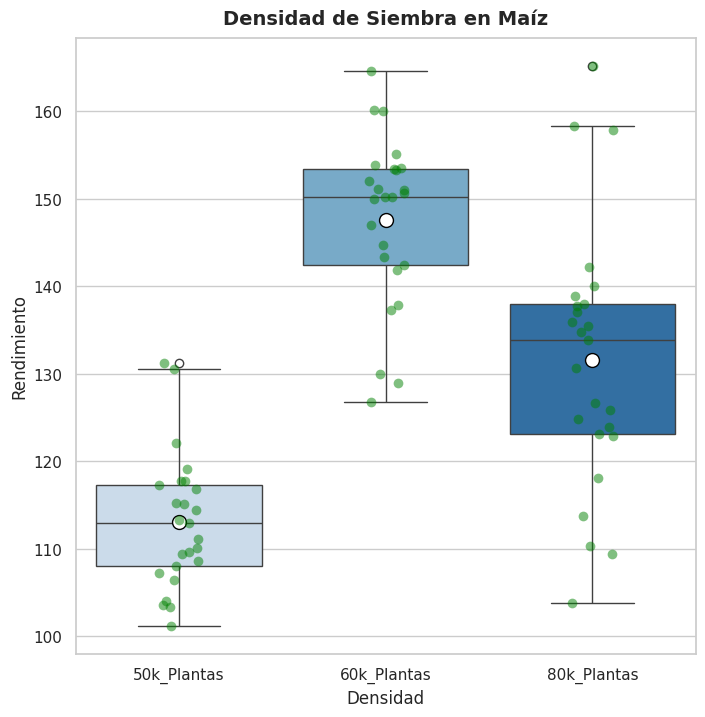

In [6]:
sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(8,8))
#Boxplot
sns.boxplot(data=df_maiz, x='Densidad', y='Rendimiento', palette='Blues', hue='Densidad', showmeans=True,\
            meanprops={'marker':'o', 'markerfacecolor':'white','markeredgecolor':'black','markersize':10})
#Dispersión
sns.stripplot(data=df_maiz, x='Densidad', y='Rendimiento', color='green', alpha=0.5, s=7)
plt.title('Densidad de Siembra en Maíz', fontsize=14, fontweight='bold',pad=10)

**Interpretación Agronómica:**
La densidad de 60.000 plantas/ha de maíz presento un rendimiento superior, con una media de 147.56qq/ha, siendo inferio a la densidad de 80.000 plantas/ha cuya media fue de 131.54 qq/ha.
Esto es debido a la constante competencia del maíz por luz, agua y nutrientes. En consecuencia las  plantas se vuelven más altas y delgadas buscando luz (etiolación). Esto consume energía que la planta debería usar para el llenado de grano, resultando en mazorcas más pequeñas o con fallas en el cierre.

## **Eficiencia de hebicida en diferentes boquillas** 🚿

Eficiencia de Herbicidas en diferentes Boquillas
Se evalúa el porcentaje de control de malezas usando 3 tipos de boquillas de pulverización: Abanico Plano, Cono Hueco y Deflectoras. Se realizan 12 repeticiones por boquilla.

In [7]:
np.random.seed(8)
# Datos de % de control (ojo: aquí simularemos una varianza desigual)
abanico = np.random.normal(85, 2, 12)
cono = np.random.normal(82, 3, 12)
deflectora = np.random.normal(75, 8, 12) # Mucha más variabilidad

datos_control = pd.DataFrame({
    'Control_Malezas': np.concatenate([abanico, cono, deflectora]),
    'Boquilla': (['Abanico']*12 + ['Cono']*12 + ['Deflectora']*12)
})

In [9]:
grupo_control = [g for n,g in datos_control.groupby('Boquilla')['Control_Malezas']] #Creamos el grupo

In [10]:
print(f"{'*'*20} RESUMEN ESTADÍSTICO {'*'*20} \n {datos_control.groupby('Boquilla')['Control_Malezas'].agg(['count','mean','std'])\
                                                  .rename(columns={'count':'Cantidad','mean':'Promedio','std':'Desviación'}).round(3)}")
print(f"\n{'*'*20} VERIFICACIÓN DE DATOS {'*'*20}")
_,p_shap = st.shapiro(datos_control['Control_Malezas'])
_,p_lev = st.levene(*grupo_control)
print(f"\nNormalidad (Shapiro): {p_shap:.3f} -> {'Ok' if p_shap>0.05 else 'Alerta'}")
print(f"Homocedasticidad (Levene): {p_lev:.3f} -> {'Ok' if p_lev>0.05 else 'Alerta'}")
print(f"\n{'*'*20} ANÁLISIS DE VARIANZA {'*'*20}")
test_func,test_name = (st.f_oneway,'ANOVA') if p_lev>0.05 else (st.kruskal,'Kruskal-Wallis')
f_stat,p_val = test_func(*grupo_control)
print(f"--- {test_name} --- \n F: {f_stat:.3f} | P value: {p_val:.3f} -> {'Significancia' if p_val<0.05 else 'No Significancia'}")
print(f"\n{'*'*20} PRUEBA POST HOC {'*'*20}")
if p_val<0.05:
  if test_name == 'ANOVA':
    print(f"{test_name} (Paramétrico) Test Tukey")
    print('\n',pairwise_tukeyhsd(endog=datos_control['Control_Malezas'], groups=datos_control['Boquilla'], alpha=0.05))
  else:
    print(f"\n{test_name} (No Paramétrico) Test Dunn")
    print(sp.posthoc_dunn(datos_control, val_col='Control_Malezas', group_col='Boquilla', p_adjust='holm'))
else:
  print("No requiere prueba POST HOC")

******************** RESUMEN ESTADÍSTICO ******************** 
             Cantidad  Promedio  Desviación
Boquilla                                  
Abanico           12    85.733       3.351
Cono              12    81.597       2.119
Deflectora        12    74.927       6.618

******************** VERIFICACIÓN DE DATOS ********************

Normalidad (Shapiro): 0.058 -> Ok
Homocedasticidad (Levene): 0.031 -> Alerta

******************** ANÁLISIS DE VARIANZA ********************
--- Kruskal-Wallis --- 
 F: 19.005 | P value: 0.000 -> Significancia

******************** PRUEBA POST HOC ********************

Kruskal-Wallis (No Paramétrico) Test Dunn
             Abanico     Cono  Deflectora
Abanico     1.000000  0.05439    0.000039
Cono        0.054390  1.00000    0.054390
Deflectora  0.000039  0.05439    1.000000


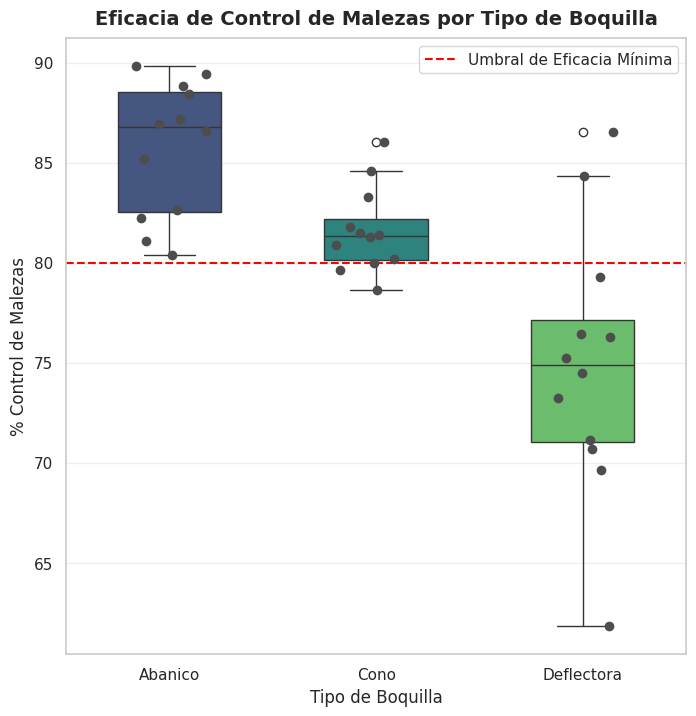

In [11]:
plt.figure(figsize=(8, 8))

# Boxplot
sns.boxplot(x='Boquilla', y='Control_Malezas', data=datos_control, palette='viridis', width=0.5,hue='Boquilla')

# Stripplot con jitter para que los puntos no se amontonen
sns.stripplot(x='Boquilla', y='Control_Malezas', data=datos_control, color='.3', size=7, jitter=0.2)

plt.title('Eficacia de Control de Malezas por Tipo de Boquilla', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Tipo de Boquilla', fontsize=12)
plt.ylabel('% Control de Malezas', fontsize=12)
plt.axhline(80, color='red', linestyle='--', label='Umbral de Eficacia Mínima') # Línea de referencia agrícola
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


*   **Decisión Estadística:** Aunque el Abanico tiene el promedio más alto (85.7), el p-valor de 0.073 entre Abanico y Cono indica que esa diferencia podría deberse al azar. Por lo tanto, se consideran similares.

*   **Variabilidad Crítica:** La desviación de la Deflectora (6.618). Es casi el triple que la del Cono. En aplicaciones de agroquímicos, la uniformidad es ley; una boquilla errática causa zonas de escape de maleza y zonas de fitotoxicidad.
*   **Criterio técnico:** La boquilla Abanico es lo ideal. Es la que destaca y presenta un control más consistente (menor desviación que la deflectora).

## **Comparación de Enmiendas para pH del Suelo** 🌱

Comparación de Enmiendas para pH del Suelo
Eres responsable de un ensayo donde se prueban 4 tipos de enmiendas para corregir la acidez de un suelo: Cal Dolomita, Cal Apagada, Silicato de Calcio y un Testigo (sin enmienda). Tras 6 meses, mides el pH en 10 puntos por tratamiento.

In [12]:
np.random.seed(15)
# Generamos datos de pH para los 4 grupos
cal_dolomita = np.random.normal(6.2, 0.3, 10)
cal_apagada = np.random.normal(6.5, 0.25, 10)
silicato = np.random.normal(5.9, 0.35, 10)
testigo = np.random.normal(4.8, 0.4, 10)

# Unimos los datos en un DataFrame para análisis
datos_ph = pd.DataFrame({
    'pH': np.concatenate([cal_dolomita, cal_apagada, silicato, testigo]),
    'Tratamiento': (['Dolomita']*10 + ['Apagada']*10 + ['Silicato']*10 + ['Testigo']*10)
})

In [13]:
grupo_ph = [g for n, g in datos_ph.groupby('Tratamiento')['pH']] #Creamos el grupo

In [14]:
print(f"{'*'*20} RESUMEN ESTADÍSTICO {'*'*20} \n {datos_ph.groupby('Tratamiento')['pH'].agg(['count','mean','std'])\
                                                   .rename(columns={'count':'Cantidad','mean':'Promedio','std':'Desviación'}).round(3)}")
print(f"\n{'*'*20} VERIFICACIÓN DE DATOS {'*'*20}")
_,p_shap = st.shapiro(datos_ph['pH'])
_,p_lev = st.levene(*grupo_ph)
print(f"\nNormalidad (Shapiro): {p_shap:.3f} -> {'Ok' if p_shap>0.05 else 'Alerta'}")
print(f"Homocedasticidad (Levene): {p_lev:.3f} -> {'Ok' if p_lev>0.05 else 'Alerta'}")
print(f"\n{'*'*20} ANÁLISIS DE VARIANZA {'*'*20}")
test_func, test_name = (st.f_oneway,'ANOVA') if p_lev>0.05 else (st.kruskal,'Kruskal-Wallis')
f_stat,p_val = test_func(*grupo_ph)
print(f"--- {test_name} --- \n F: {f_stat:.3f} | P Value: {p_val:.3f} -> {'Significancia' if p_val<0.05 else 'No Significancia'} ")
print(f"\n{'*'*20} PRUEBA POST HOC {'*'*20}")
if p_val < 0.05:
    if test_name == 'ANOVA':
        posthoc = pairwise_tukeyhsd(endog=datos_ph['pH'], groups=datos_ph['Tratamiento'], alpha=0.05)
        print(f"Prueba: Tukey HSD (Paramétrica)\n{posthoc}")
    else:
        p_dunn = sp.posthoc_dunn(datos_ph, val_col='pH', group_col='Tratamiento', p_adjust='holm')
        print(f"Prueba: Dunn (No Paramétrica - p-ajustado: Holm)\n{p_dunn.round(4)}")
else:
    print(f"Resultado: p-value {p_val:.3f} >= 0.05. No se requiere análisis Post Hoc")


******************** RESUMEN ESTADÍSTICO ******************** 
              Cantidad  Promedio  Desviación
Tratamiento                                
Apagada            10     6.586       0.153
Dolomita           10     6.046       0.193
Silicato           10     5.881       0.423
Testigo            10     4.562       0.468

******************** VERIFICACIÓN DE DATOS ********************

Normalidad (Shapiro): 0.001 -> Alerta
Homocedasticidad (Levene): 0.016 -> Alerta

******************** ANÁLISIS DE VARIANZA ********************
--- Kruskal-Wallis --- 
 F: 31.913 | P Value: 0.000 -> Significancia 

******************** PRUEBA POST HOC ********************
Prueba: Dunn (No Paramétrica - p-ajustado: Holm)
          Apagada  Dolomita  Silicato  Testigo
Apagada    1.0000    0.0295    0.0091   0.0000
Dolomita   0.0295    1.0000    0.5923   0.0094
Silicato   0.0091    0.5923    1.0000   0.0295
Testigo    0.0000    0.0094    0.0295   1.0000


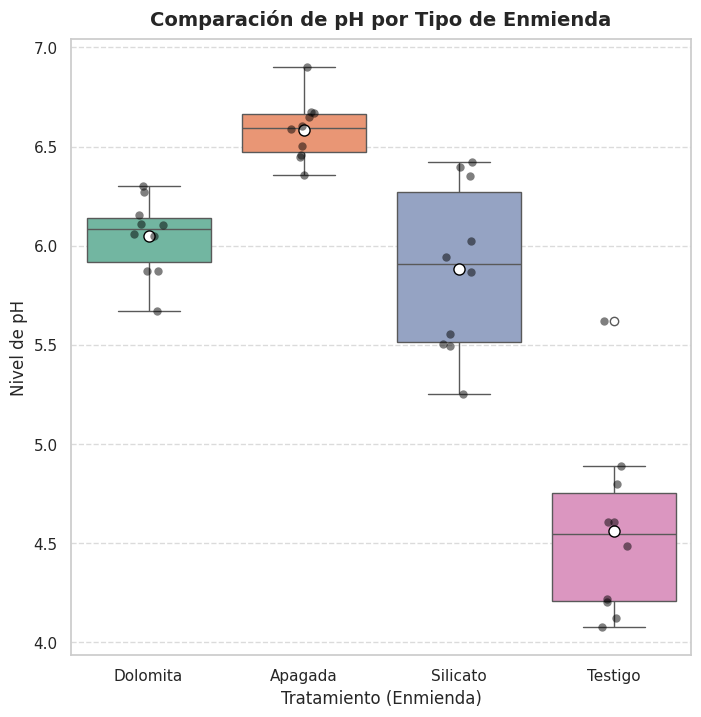

In [15]:
plt.figure(figsize=(8, 8))

# Dibujamos el Boxplot de fondo
sns.boxplot(x='Tratamiento', y='pH', data=datos_ph, palette='Set2', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}, hue='Tratamiento')

# Superponemos el Stripplot para ver los puntos individuales
sns.stripplot(x='Tratamiento', y='pH', data=datos_ph, color='black', alpha=0.5, size=6, jitter=True)

plt.title('Comparación de pH por Tipo de Enmienda', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Tratamiento (Enmienda)', fontsize=12)
plt.ylabel('Nivel de pH', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



*   **Decisión Estadística:** Correcto. Al ser p<0.05 en el análisis global, la prueba de Tukey confirma que la Cal Apagada es la ganadora absoluta (Promedio 6.586).

*   **Interpretación Agronómica:** La Cal Dolomita y el Silicato son estadísticamente iguales entre sí, pero inferiores a la Cal Apagada.

*   **Tu criterio económico:** La Cal Apagada es la más económica por ende al elegirla es una decisión ganadora porque, además de ser la más efectiva para subir el pH (según los datos), se estaría optimizando el costo por punto de pH incrementado.







